# imports

In [27]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    classification_report, accuracy_score, 
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import mlflow
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# config

In [20]:
ASSET = "BTC"
INTERVAL = "1h"
VERSION = "v2"
HORIZON = "4h"
BASELINE_V2_ACCURACY = 0.5261 #v2's result

# Load V2 Data (with OI & Turnover Features)

In [21]:
train_df = pd.read_parquet('../../../data/processed/train_btc_1h_4h_target.parquet')
test_df  = pd.read_parquet('../../../data/processed/test_btc_1h_4h_target.parquet')

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Features: {[c for c in train_df.columns if c not in ['target_4h', 'target_direction']]}")

Train: (40558, 39)
Test:  (10140, 39)
Features: ['rsi_14', 'roc_10', 'roc_20', 'stoch_k', 'stoch_d', 'bb_percentage', 'volume_ratio', 'returns_1p', 'returns_5p', 'returns_10p', 'returns_20p', 'log_returns', 'hl_ratio', 'close_position', 'oi_change_1p', 'oi_change_5p', 'oi_change_20p', 'oi_zscore_50', 'turnover_ratio', 'turnover_change_1p', 'turnover_change_5p', 'turnover_ratio_zscore_50', 'sma_7_dist', 'sma_30_dist', 'sma_50_dist', 'sma_100_dist', 'sma_200_dist', 'ema_12_dist', 'ema_26_dist', 'ema_50_dist', 'ema_200_dist', 'vwap_dist', 'macd_pct', 'macd_sig_pct', 'macd_hist_pct', 'atr_pct', 'volatility_pct']


# Separate Targets from Features

In [22]:
y_train = train_df.pop('target_direction')
X_train = train_df.drop(columns=['target_4h'], errors='ignore')

y_test = test_df.pop('target_direction')
X_test = test_df.drop(columns=['target_4h'], errors='ignore')

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"Class balance (test): UP={(y_test==1).mean():.2%}  DOWN={(y_test==0).mean():.2%}")

X_train: (40558, 37)  |  y_train: (40558,)
X_test:  (10140, 37)   |  y_test:  (10140,)
Class balance (test): UP=50.29%  DOWN=49.71%


# MLflow 

In [23]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(f"{ASSET}_{INTERVAL}_{HORIZON}_XGBoost")
mlflow.xgboost.autolog(disable=True)

# baseline model (withouyt tuning)

In [24]:
with mlflow.start_run(run_name=f"{ASSET}_{HORIZON}_XGBoost_Baseline"):
    mlflow.log_param("asset", ASSET)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("horizon", HORIZON)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("run_type", "baseline")
    
    baseline_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        device='cuda',
        tree_method='hist',
        eval_metric='logloss',
        random_state=42
    )
    
    baseline_model.fit(X_train, y_train)
    y_pred_baseline = baseline_model.predict(X_test)
    
    baseline_acc  = accuracy_score(y_test, y_pred_baseline)
    baseline_prec = precision_score(y_test, y_pred_baseline)
    baseline_rec  = recall_score(y_test, y_pred_baseline)
    baseline_f1   = f1_score(y_test, y_pred_baseline)
    
    mlflow.log_params({
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 5
    })
    mlflow.log_metric("test_accuracy", baseline_acc)
    mlflow.log_metric("test_precision", baseline_prec)
    mlflow.log_metric("test_recall", baseline_rec)
    mlflow.log_metric("test_f1", baseline_f1)
    
    print(f"BASELINE ({HORIZON} target):")
    print(f"  Accuracy:  {baseline_acc:.4f}")
    print(f"  Precision: {baseline_prec:.4f}")
    print(f"  Recall:    {baseline_rec:.4f}")
    print(f"  F1:        {baseline_f1:.4f}")
    print(classification_report(y_test, y_pred_baseline, target_names=['DOWN', 'UP']))

BASELINE (4h target):
  Accuracy:  0.5126
  Precision: 0.5151
  Recall:    0.5260
  F1:        0.5205
              precision    recall  f1-score   support

        DOWN       0.51      0.50      0.50      5041
          UP       0.52      0.53      0.52      5099

    accuracy                           0.51     10140
   macro avg       0.51      0.51      0.51     10140
weighted avg       0.51      0.51      0.51     10140

🏃 View run BTC_4h_XGBoost_Baseline at: http://localhost:5000/#/experiments/18/runs/61a8492363894baaafdaed0860325eea
🧪 View experiment at: http://localhost:5000/#/experiments/18


# GridSearchCV 
# 216 candidates same as v2

In [25]:
with mlflow.start_run(run_name=f"{ASSET}_{HORIZON}_XGBoost_GridSearch"):
    mlflow.log_param("asset", ASSET)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("horizon", HORIZON)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("baseline_v2_accuracy", BASELINE_V2_ACCURACY)
    mlflow.log_param("run_type", "grid_search")
    
    param_grid = {
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.01, 0.05, 0.1],
        'n_estimators':     [100, 200, 300],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_alpha':        [0, 0.1],
    }
    
    total_combos = (
        len(param_grid['max_depth']) *
        len(param_grid['learning_rate']) *
        len(param_grid['n_estimators']) *
        len(param_grid['subsample']) *
        len(param_grid['colsample_bytree']) *
        len(param_grid['reg_alpha'])
    )
    print(f"Grid: {total_combos} candidates × 3 folds = {total_combos * 3} total fits")
    
    base_xgb = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    )
    
    grid_search = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test)
    
    tuned_acc  = accuracy_score(y_test, y_pred_tuned)
    tuned_prec = precision_score(y_test, y_pred_tuned)
    tuned_rec  = recall_score(y_test, y_pred_tuned)
    tuned_f1   = f1_score(y_test, y_pred_tuned)
    
    delta_vs_baseline = tuned_acc - baseline_acc
    delta_vs_v2       = tuned_acc - BASELINE_V2_ACCURACY
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("test_accuracy",  tuned_acc)
    mlflow.log_metric("test_precision", tuned_prec)
    mlflow.log_metric("test_recall",    tuned_rec)
    mlflow.log_metric("test_f1",        tuned_f1)
    mlflow.log_metric("delta_vs_baseline_4h", delta_vs_baseline)
    mlflow.log_metric("delta_vs_v2_1h",       delta_vs_v2)
    
    print(f"\nGRID SEARCH ({HORIZON} target):")
    print(f"  Best Params: {grid_search.best_params_}")
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy:  {tuned_acc:.4f}")
    print(f"  Test Precision: {tuned_prec:.4f}")
    print(f"  Test Recall:    {tuned_rec:.4f}")
    print(f"  Test F1:        {tuned_f1:.4f}")
    print(classification_report(y_test, y_pred_tuned, target_names=['DOWN', 'UP']))


Grid: 216 candidates × 3 folds = 648 total fits
Fitting 3 folds for each of 216 candidates, totalling 648 fits

GRID SEARCH (4h target):
  Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0, 'subsample': 1.0}
  Best CV Score: 0.5394
  Test Accuracy:  0.5243
  Test Precision: 0.5284
  Test Recall:    0.5021
  Test F1:        0.5149
              precision    recall  f1-score   support

        DOWN       0.52      0.55      0.53      5041
          UP       0.53      0.50      0.51      5099

    accuracy                           0.52     10140
   macro avg       0.52      0.52      0.52     10140
weighted avg       0.52      0.52      0.52     10140

🏃 View run BTC_4h_XGBoost_GridSearch at: http://localhost:5000/#/experiments/18/runs/66d62d01f2654cde8f0d9b7cdec81d87
🧪 View experiment at: http://localhost:5000/#/experiments/18


# Feature Importance (from best model)

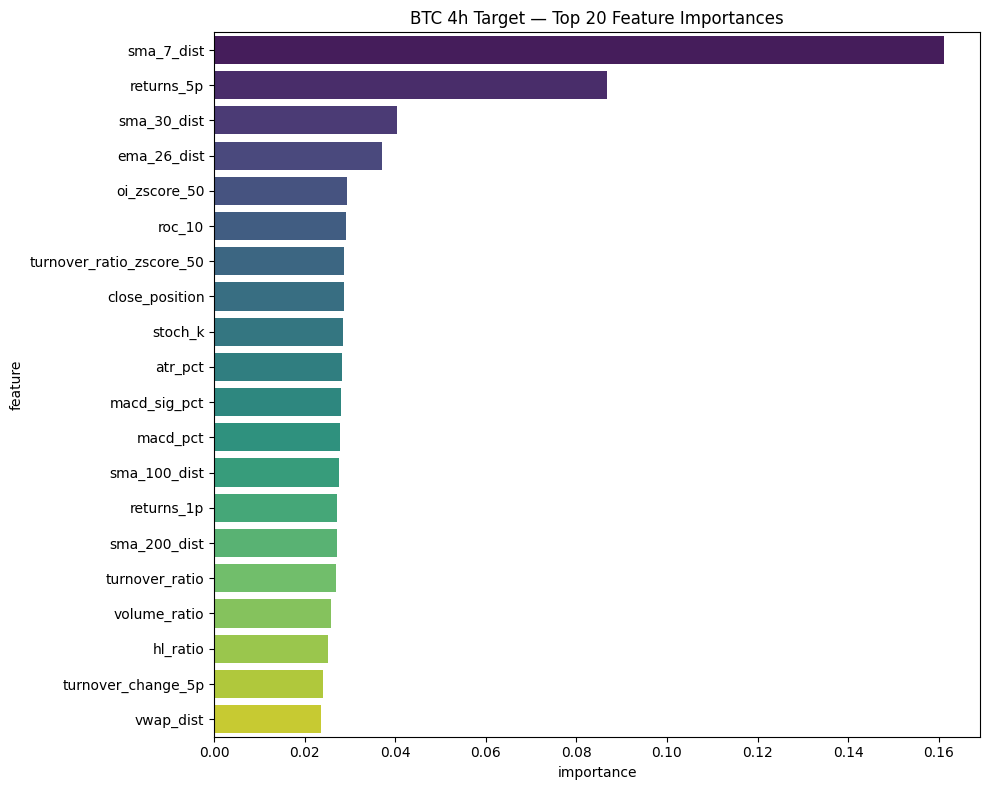

Top 10 features:
                 feature  importance
              sma_7_dist    0.161065
              returns_5p    0.086835
             sma_30_dist    0.040269
             ema_26_dist    0.037078
            oi_zscore_50    0.029266
                  roc_10    0.029209
turnover_ratio_zscore_50    0.028746
          close_position    0.028666
                 stoch_k    0.028360
                 atr_pct    0.028180


In [28]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), y='feature', x='importance', palette='viridis')
plt.title(f'{ASSET} {HORIZON} Target — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

# confusion matrix

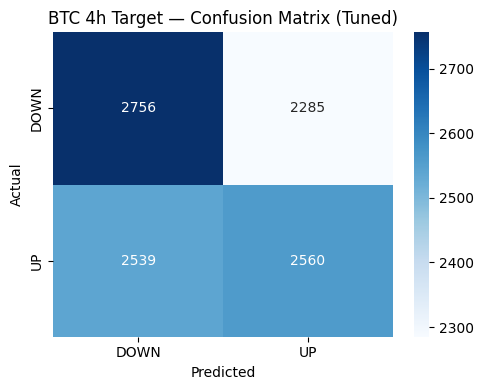

In [29]:
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['DOWN', 'UP'], yticklabels=['DOWN', 'UP'])
plt.title(f'{ASSET} {HORIZON} Target — Confusion Matrix (Tuned)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# summary

In [30]:
print("=" * 55)
print(f"   RESULTS: {ASSET} 1h features → {HORIZON} Target")
print("=" * 55)
print(f"  v2 Baseline (OI+turnover, 1h target): {BASELINE_V2_ACCURACY:.4f}")
print(f"  4h Baseline (no tuning):              {baseline_acc:.4f}  {'↑' if baseline_acc > BASELINE_V2_ACCURACY else '↓'} {'IMPROVEMENT!' if baseline_acc > BASELINE_V2_ACCURACY else 'No improvement'}")
print(f"  4h Tuned (GridSearchCV):              {tuned_acc:.4f}  {'↑' if tuned_acc > BASELINE_V2_ACCURACY else '↓'} {'IMPROVEMENT!' if tuned_acc > BASELINE_V2_ACCURACY else 'No improvement'}")
print(f"  Best Params: {grid_search.best_params_}")
print(f"  GridSearch improvement over baseline: {delta_vs_baseline:+.4f}")
print("=" * 55)
print(f"\nInterpretation:")
print(f"  - v2 ceiling (1h):  {BASELINE_V2_ACCURACY:.4f}")
print(f"  - If 4h tuned > {BASELINE_V2_ACCURACY:.4f}: longer horizon captured signal")
print(f"  - If 4h tuned ≈ {BASELINE_V2_ACCURACY:.4f}: no benefit from longer horizon")

   RESULTS: BTC 1h features → 4h Target
  v2 Baseline (OI+turnover, 1h target): 0.5261
  4h Baseline (no tuning):              0.5126  ↓ No improvement
  4h Tuned (GridSearchCV):              0.5243  ↓ No improvement
  Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0, 'subsample': 1.0}
  GridSearch improvement over baseline: +0.0116

Interpretation:
  - v2 ceiling (1h):  0.5261
  - If 4h tuned > 0.5261: longer horizon captured signal
  - If 4h tuned ≈ 0.5261: no benefit from longer horizon
